This notebook aims to debug my current ccsa custom implementation and check wheter my adaptation can make it more parameter-independent. We will first focus on diminishing the potential differences with the NLOPT implementation, then provide possible alternatives for the adaptation of parameters like the trust region, the curvature, w, parameter for the control of the curvature update. Finally we will understand how stochasticity affects this and how we can change the acceptance criterion to be suitable for stochastic optimization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt
import torch

from ccsa_mma import MMAOptimizer

In [2]:
def adam(fgrad, xinit, ferr=None, f=None, tol=1e-8, maxiters=1000,
         alpha=0.001, eps=1e-8, beta1=0.9, beta2=0.999):
    
    
    x = xinit

    # initial residual and norms
    if ferr:
        errs = [ferr(x)]

    if f:
        vals = [f(x)]
        print(vals)

    # initial Adam state
    mom = np.zeros_like(x)  # first moment (m)
    var = np.zeros_like(x)  # second moment (v)

    for i in range(1, maxiters + 1):
        grad = fgrad(x)
        
        # Adam-style moments on the residual
        mom = beta1 * mom + (1.0 - beta1) * grad
        var = beta2 * var + (1.0 - beta2) * (grad * grad)

        # bias corrections
        mhat = mom / (1.0 - beta1**i)
        vhat = var / (1.0 - beta2**i)

        # parameter update
        x = x - alpha * (mhat / (np.sqrt(vhat) + eps))

        if f:
            vals.append(f(x))
        if ferr:
            err = ferr(x)
            errs.append(err)
            if err <= tol:
                break

    if ferr:
        if f:
            return x, vals, errs
        else:
            return x, errs
    else:
        if f:
            return x, vals
        else:
            return x


## Unconstrained Stochastic Convex Optimization:

Let's try the stochastic optimization problem
$$
\min_{x \in \mathbb{R}^n} E[f(x,\xi)]
$$
where
$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2
$$
and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$

The expectation value $E[\cdots]$ is for $\xi$ drawn from i.i.d. Gaussian random variables $\xi_k \sim N(0,\sigma^2)$.

Analytically, the minimizer should simply be at $x = 0$ while the minimum is $ \sigma^2 \mathrm{tr}(A^2)$.

Note that $\nabla_x f = 2A(x + \xi)$.

Our starting guess will simply be `x = randn(n)`, and we'll use $A = I$ to start with.

In [3]:
# random nxn matrix with condition number κ and log-spaced singular values
def randcond(n, κ):
    Q, R = np.linalg.qr(np.random.randn(n, n))
    Q = Q @ np.diag(np.sign(np.diag(R))) # randomize signs
    σ = np.logspace(np.log10(1), np.log10(1/κ), num=n)
    return Q @ np.diag(σ) @ Q.T

In [4]:
# Useful plotting utils 

def make_red_colors(k):
    cmap = plt.cm.plasma
    if k > 1:
        return [cmap(0.3 + 0.6 * i/(k-1)) for i in range(k)]
    else:
        return [cmap(0.3 + 0.6 * 0)]

[5.974100872109246]
Metrics for new CCSA with σ_min=0.1:
Metrics for new CCSA with σ_min=1e-05:


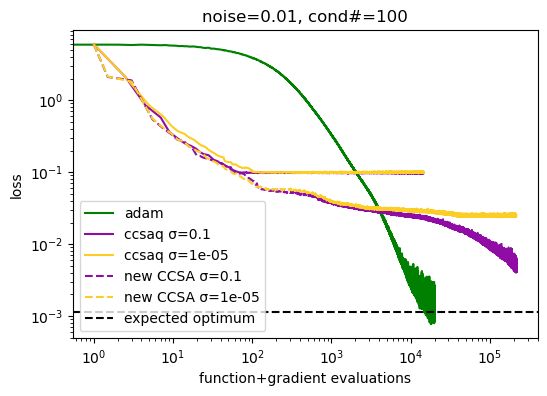

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt
import torch
from ccsa_mma import MMAOptimizer  # Assuming your custom optimizer is imported from ccsa_mma.py

# make_red_colors should be in scope as in your original script

# Modified run_stochastic_exp to include the new CCSA implementation (with rng & single-sample oracle)
def run_stochastic_exp(noise, cond, sigma_mins, seed=42):
    # deterministic RNG for the experiment
    rng = np.random.RandomState(seed)

    n = 100
    A = np.eye(n) if cond == 1 else randcond(n, cond)

    # sample generator (single source)
    def sample_xi():
        return rng.randn(n) * noise

    # Returns the analytical noisy gradient and function using the same sample per call
    def make_noisy_f_and_grad(A, sample_xi):
        def f_and_grad(x, grad=None):
            xi = sample_xi()           # single random sample
            p = A.dot(x + xi)
            val = float(np.linalg.norm(p)**2)
            grad_val = 2.0 * (A.T.dot(p))

            # Support both NLopt-style and MMAOptimizer-style calls
            if grad is True:
                return val, grad_val
            if isinstance(grad, np.ndarray):
                grad[:] = grad_val
                return val
            return val
        return f_and_grad


    oracle = make_noisy_f_and_grad(A, sample_xi)

    # For Adam: adaptors so adam receives gradient and function (but both use same sample in each call)
    def f_for_adam(x):
        # return f(x) (no gradient requested) -> uses its own sample
        return oracle(x, grad=None)

    def fgrad_for_adam(x):
        # return gradient array (adam expects this interface in your code)
        grad = np.zeros_like(x)
        oracle(x, grad=grad)
        return grad

    # Computes the error with respect to the minimizer
    def ferr(x):
        return np.linalg.norm(x)

    x_init = rng.randn(n)

    # Adam run (now consistent sampling because we call oracle inside these adaptors)
    x, vals, errs = adam(xinit=x_init, fgrad=fgrad_for_adam, ferr=ferr, f=f_for_adam, maxiters=2*10**4)

    # Plot setup
    plt.figure(figsize=(6, 4))
    plt.plot(vals, "g-", label="adam")
    colors = make_red_colors(len(sigma_mins))

    # Multiple CCSA runs with different sigma_min using NLopt library
    for sigma_min, color in zip(sigma_mins, colors):
        opt = nlopt.opt(nlopt.LD_MMA, n)

        evals = 0
        f_evals, x_errs, f_vals = [], [], []

        # Noisy function and gradient evaluations with counter using our convention.
        # This version draws a single xi per call and returns consistent value+grad.
        def f_and_grad_nlopt(x, grad):
            nonlocal evals, f_evals, x_errs
            xi = sample_xi()   # NLopt block uses same RNG
            p = A.dot(x + xi)
            val = float(np.linalg.norm(p)**2)
            if grad.size > 0:
                grad[:] = 2 * (A.T @ p)
                evals += 1
                f_evals.append(evals)
                x_errs.append(np.linalg.norm(x))
                f_vals.append(val)
            else:
                evals += 0.5
            return val

        opt.set_param("inner_gradients", 0)
        opt.set_param("always_improve", 0)
        opt.set_param("sigma_min", sigma_min)
        opt.set_param("inner_maxeval", 5)
        opt.set_min_objective(f_and_grad_nlopt)
        opt.set_maxeval(10000)

        xopt = opt.optimize(x_init)
        plt.loglog(np.asarray(f_evals), f_vals, label=f"ccsaq σ={sigma_min}", color=color)

    # Adding the new CCSA implementation (use same oracle defined above)
    for sigma_min, color in zip(sigma_mins, colors):
        x_tensor = torch.tensor(x_init, dtype=torch.float32, requires_grad=True)
        optimizer = MMAOptimizer(
            params=[x_tensor],
            fun=oracle,   # oracle returns value or value+grad depending on grad arg
            g=None,
            x0 = x_init,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            sigma_min=sigma_min,
            df=None,      
            dg=None
        )

        all_x = []
        n_outer = 100000
        for outer in range(n_outer):
            f_b, g_b, metrics = optimizer.step()
            all_x.append(metrics["x_history"][-1])

        # metrics now contains the x_history and cumulative_weighted_evals_history
        x_hist = metrics["x_history"]                                  # shape (k, n)
        cum_we_hist = metrics["cumulative_weighted_evals_history"]    # shape (k,)

        print(f"Metrics for new CCSA with σ_min={sigma_min}:")
        # For demonstration, compute function value at each stored x in x_hist using the oracle *but keep rng deterministic*:
        # NOTE: if you want to replay with same draw-per-evaluation semantics, ensure rng state is managed externally.
        f_at_xhist = [oracle(xi, grad=None) for xi in x_hist]

        plt.loglog(cum_we_hist, f_at_xhist, linestyle="--", color=color,
                   label=f"new CCSA σ={sigma_min}")

    # The expected optimum depends on the noise level and the condition number
    f_star = noise**2 * np.trace(A.T @ A)
    plt.axhline(y=f_star, color="k", linestyle="--", label="expected optimum")

    plt.legend()
    plt.xlabel("function+gradient evaluations")
    plt.ylabel("loss")
    plt.title(f"noise={noise}, cond#={cond}")
    plt.xscale("log")
    plt.yscale("log")
    plt.show()

    optimizer.summarize_diagnostics()


# Run experiments for the new implementation
for noise in [0.01]:
    for cond in [100]:
        run_stochastic_exp(noise=noise, cond=cond, sigma_mins=[1e-1, 1e-5], seed=42)




## CONVEX STOCHASTIC OBJECTIVE DETERMINISTIC LINEAR CONSTRAINT

Let's define our first constrained optimization algorithm. We will start with a simple case in which we just take the above and modify with a simple linear constraint. 

$$
\min_{x \in \mathbb{R}^n} \; \mathbb{E}[f(x,\xi)] \quad \quad s.t. \quad c^T x - b \leq 0
$$

where  

$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2, 
$$  

and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$ is a random vector with $\mathbb{E}[\xi]=0$ and $\mathrm{Cov}(\xi) = \sigma_\xi^2 I$. We will divide it into 2 cases:

1.  Active Constraint (i.e. unconstrained solution is NOT in the feasible region). In this case the solution lies on the feasibility boundary and can be analytically computed by forming the lagrangian starting from the expected valued function (ignoring for the moment the noise related term)

$$
\mathcal{L}(x,\lambda) = x^T A^2 x + \lambda (c^T x - b).
$$

The KKT condition gives us

$$
\nabla_x \mathcal{L} = 2 A^2 x + \lambda c = 0 
\quad \Longrightarrow \quad 
x = -\frac{\lambda}{2} (A^2)^{-1} c.
$$

Impose the constraint \(c^T x = b\):

$$
c^T \Big(-\frac{\lambda}{2} (A^2)^{-1} c \Big) = b
\quad \Longrightarrow \quad
\lambda = -\frac{2b}{c^T (A^2)^{-1} c}.
$$

Hence the constrained optimizer is

$$
x^\ast_{\text{constr}} 
= \frac{b}{c^T (A^2)^{-1} c} \, (A^2)^{-1} c.
$$


To obtain the optimum we plug into the objective:

$$
F(x^\ast_{\text{constr}})
= (x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$

The quadratic term evaluates to

$$
(x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}}
= \frac{b^2}{c^T (A^2)^{-1} c}.
$$

and the final optimal value is

$$
F^\ast_{\text{constr}} 
= \frac{b^2}{c^T (A^2)^{-1} c} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$



2. Inactive Constraint (i.e. unconstrained solution is in the feasible region). In this case, similarly as before, the expected optimum is $\sigma^2 \mathrm{tr}(A^2) $.  

---

As a baseline we implement the augmented lagrangian version of Adam, which is a state-of-the-art method for constrained stochastic optimization.  

The augmented Lagrangian for our problem is defined as  

$$
\mathcal{L}_\rho(x, \lambda) = \mathbb{E}[f(x,\xi)] + \lambda \, (c^\top x - d) + \tfrac{\rho}{2} \, (c^\top x - d)^2,
$$  

where $\lambda \ge 0$ is the Lagrange multiplier and $\rho > 0$ is a penalty parameter.  

At each iteration $k$ we should perform a stochastic Adam update on the primal variable $x$ using $g_k$, a stochastic estimate of the gradient of the augmented Lagrangian,  

$$
g_k = \nabla f(x_k, \xi_k) + (\lambda_k + \rho \, g(x_k)) c,
$$  

with constraint function $g(x) = c^\top x - d$.  

The dual variable is updated at each step according to  

$$
\lambda_{k+1} = \max \big( 0, \lambda_k + \rho \, g(x_{k+1}) \big).
$$  

This results in a single-loop primal-dual method where the primal variable is updated using Adam with stochastic gradients, and the dual variable is updated via a projected gradient descent step to enforce feasibility.


In [10]:
# Adam Augmented Lagrangian 

def adam_augmented_lagrangian(fgrad, x0, c, b, rho=1.0, lambda0=0.0,
                              alpha=1e-3, maxiters=500000, tol=1e-8,
                              beta1=0.9, beta2=0.999, eps=1e-8,
                              update_lambda_every=100, log_every=1,
                              f_stoch_estimate=None, constraint_val=None,
                              rho_multiplier=2.0, rho_update_freq=5000, total_outer=0, tol_outer=1e-4, rho_update_max=10, inner_kwargs=None, max_outer=None, verbose=None):
    
    # Initialization of primal x, dual multiplier lambda, and Adam state
    x = x0.copy()
    lam = float(lambda0)   # dual            
    mom = np.zeros_like(x)  # first moment       
    var = np.zeros_like(x)  # second moment          
    
    hist = {'iter': [], 'f_est': [], 'g': [], 'norm_x': [], 'lambda': []}
    total_grad_evals = 0.0              

    for k in range(1, maxiters + 1):
        # primal step
        g_f = fgrad(x)                  
        total_grad_evals += 1.0
        g_val = float(np.dot(c, x) - b) 

        # augmented Lagrangian gradient
        #gL = g_f + (lam + rho * g_val) * c
        gL = g_f + max(0.0, lam + rho * g_val) * c


        # update first and second moment estimates
        mom = beta1 * mom + (1.0 - beta1) * gL
        var = beta2 * var + (1.0 - beta2) * (gL * gL)

        # bias correction
        mhat = mom / (1.0 - beta1**k)
        vhat = var / (1.0 - beta2**k)

        # Adam update x
        x = x - alpha * (mhat / (np.sqrt(vhat) + eps))

        # dual step
        if (k % update_lambda_every) == 0:
            g_val = float(np.dot(c, x) - b)
            lam = max(0.0, lam + rho * g_val)     # lambda must be non-negative for inequality

        '''if abs(g_val) > tol_outer:     # only increase rho if constraint not satisfied
            rho *= rho_multiplier'''


        # log
        f_est = f_stoch_estimate(x) if f_stoch_estimate else np.nan
        total_grad_evals += 1.0           
        hist['iter'].append(k)
        hist['f_est'].append(f_est)           
        hist['g'].append(g_val)               
        hist['norm_x'].append(np.linalg.norm(x))
        hist['lambda'].append(lam)

        # stop if constraint satisfied and step is small
        if abs(g_val) <= 1e-6 and np.linalg.norm(mhat / (np.sqrt(vhat) + eps)) < tol:
            break

    hist['total_grad_evals'] = total_grad_evals
    return x, lam, hist


=== Running noise = 0.0, cond# = 100 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=10.1942, λ*=0.00567256
  E[f(x*)]=0.0141814 (noise const=0)
Unconstrained baseline: E[f(x_uncon)]= 0, g(x_uncon)=5
Initial constraint g(x0)=6.20258 (init_feasible=False)

AL-Adam finished:
  last f_est=0.0141819, g(x)=4.09511e-05, λ=0.00572127

MMA σ=1e-06: res=5, ||x||=9.59, g(x)=-1.2e-05
CCSA σ=1e-06: cumulative_wval=107.032, weighted_evals=169.0, x_history_len=101


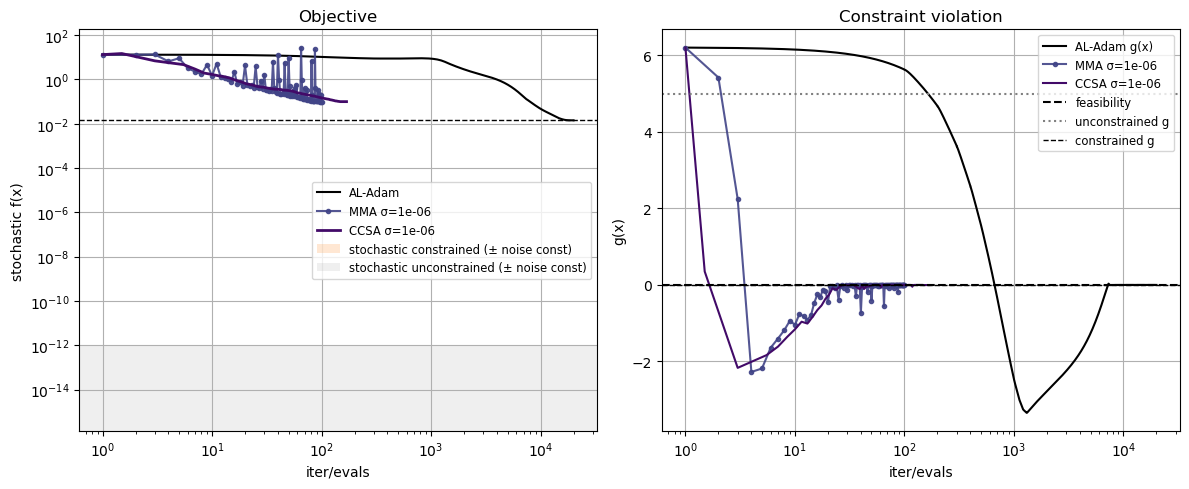

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt
import torch
from ccsa_mma import MMAOptimizer  

import os, random

seed = 0
# global numpy legacy RNG
np.random.seed(seed)
# python stdlib
random.seed(seed)
# explicit RandomState you already use
rng = np.random.RandomState(seed)
# new recommended Generator (if you prefer)
# rng2 = np.random.default_rng(seed)
# torch
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# ---------------------------
# Helper: initialize x0 feasible or infeasible (kept as top-level but not used inside run)
# ---------------------------
def init_point(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = np.random.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

def run_convex_stoch_det_constraint_exp(
    noise: float = 0.2,
    cond: int = 1,
    sigma_mins: list = [0.0, 0.01, 0.1],
    seed: int = 0,
    maxiters_adam: int = 20000,
    mma_maxeval: int = 2000,
    active_constraint = True,
    init_feasible: bool = False,
    inner_kwargs = None,
    rho: float = 1.0,
    lambda0: float = 0.0,
    tol_outer: float = 1e-6,
    rho_multiplier: float = 2.0,
    rho_update_max: int = 6,
    max_outer = 8,
    verbose: bool = True,
    ccsa_plot_expected: bool = True,
    ccsa_n_outer: int = 100
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import nlopt

    # deterministic RNG for this experiment (single source)
    rng = np.random.RandomState(seed)

    n = 100
    A = np.eye(n) if cond == 1 else randcond(n, cond)
    A2 = A.T @ A
    traceA2 = float(np.trace(A2))

    # random linear constraint
    c = rng.randn(n)
    c /= np.linalg.norm(c)
    x_uncon = np.zeros(n)
    if active_constraint is None:
        b = rng.uniform(-1, 1)
    elif active_constraint:
        b = np.dot(c, x_uncon) - 5.0
    else:
        b = np.dot(c, x_uncon) + 5.0

    print(f"Random constraint: ||c||={np.linalg.norm(c):.6g}, b={b:.6g}")

    # analytic expected optimum
    def analytic_solution_expectation(A, c, b, noise):
        A2 = A.T @ A
        s = np.linalg.solve(A2, c)
        denom = float(c.dot(s))
        if b >= 0:
            x_star = np.zeros_like(c)
            lambda_star = 0.0
            active_flag = False
        else:
            x_star = (b / denom) * s
            lambda_star = -2.0 * b / denom
            active_flag = True
        const_term = (noise**2) * np.trace(A2)
        val = float(x_star.dot(A2.dot(x_star))) + const_term
        return x_star, lambda_star, active_flag, val, const_term

    x_star, lambda_star, active_flag, val_star, const_term = analytic_solution_expectation(A, c, b, noise)
    print("Analytic expected optimum (on expectation):")
    print(f"  active? {active_flag}")
    print(f"  ||x*||={np.linalg.norm(x_star):.6g}, λ*={lambda_star:.6g}")
    print(f"  E[f(x*)]={val_star:.6g} (noise const={const_term:.6g})")

    val_uncon = const_term
    g_uncon = -b
    print(f"Unconstrained baseline: E[f(x_uncon)]= {val_uncon:.6g}, g(x_uncon)={g_uncon:.6g}")

    # --- deterministic sampling closure used by all function/grad calls in this run ---
    def sample_xi():
        return rng.randn(n) * noise

    # stochastic helpers that use sample_xi (keeps value/grad consistent if caller uses same xi)
    def fgrad_stoch(x):
        # returns gradient only (draws a sample)
        xi = sample_xi()
        #return 2.0 * (A.T @ A @ (x + xi))
        return 2.0 * (A.T @ A @ (x))

    def f_stoch_estimate(x):
        xi = sample_xi()
        #return float(np.linalg.norm(A.dot(x + xi))**2)
        return float(np.linalg.norm(A.dot(x))**2)

    def expected_f(x):
        return float(np.linalg.norm(A.dot(x))**2 + (noise**2) * traceA2)

    def constraint_val(x):
        return float(np.dot(c, x) - b)

    # init point (local version using rng)
    def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
        x0 = rng.randn(n)
        g0 = float(np.dot(c, x0) - b)
        if force_feasible:
            if g0 > 0:
                delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
                x0 = x0 + delta
        else:
            if g0 <= 0:
                delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
                x0 = x0 + delta
        return x0

    x0 = init_point_local(n, c, b, force_feasible=init_feasible)
    print(f"Initial constraint g(x0)={constraint_val(x0):.6g} (init_feasible={init_feasible})")
    print()

    if inner_kwargs is None:
        inner_kwargs = {'alpha':1e-3,'batch_size':16,'patience':10,'tol_step':1e-5,'tol_g':1e-4,'max_inner':None,'verbose':False,'log_every':200}

    # run AL-Adam (assumes function exists). We keep calling the same fgrad_stoch / f_stoch_estimate
    x_al, lam_al, hist_al = adam_augmented_lagrangian(
        fgrad=fgrad_stoch,
        x0=x0.copy(),
        c=c,
        b=b,
        rho=rho,
        lambda0=lambda0,
        f_stoch_estimate=f_stoch_estimate,
        tol_outer=tol_outer,
        maxiters=maxiters_adam,
        rho_multiplier=rho_multiplier,
        rho_update_max=rho_update_max,
        inner_kwargs=inner_kwargs,
        max_outer=max_outer,
        verbose=verbose
    )

    print("AL-Adam finished:")
    last_f_est = hist_al['f_est'][-1] if len(hist_al['f_est'])>0 else np.nan
    last_g = hist_al['g'][-1] if len(hist_al['g'])>0 else constraint_val(x_al)
    print(f"  last f_est={last_f_est:.6g}, g(x)={last_g:.6g}, λ={lam_al:.6g}")
    print()

    # NLopt-MMA (unchanged except it now uses sample_xi from same rng)
    mma_results = []
    colors_mma = plt.cm.viridis(np.linspace(0.2, 0.8, len(sigma_mins)))
    for sigma_min, color in zip(sigma_mins, colors_mma):
        opt = nlopt.opt(nlopt.LD_MMA, n)
        evals = 0.0
        mma_f_evals, mma_g_vals, mma_f_vals = [], [], []
        def f_and_grad_mma(x, grad):
            nonlocal evals, mma_f_evals, mma_g_vals, mma_f_vals
            xi = sample_xi()       # same RNG sequence
            p = A.dot(x + xi)
            val = float(np.linalg.norm(p)**2)
            if grad.size > 0:
                grad[:] = 2.0 * (A.T.dot(p))
                evals += 1
                mma_f_evals.append(evals)
                mma_f_vals.append(val)
                mma_g_vals.append(constraint_val(x))
            else:
                evals += 0.5
            return val
        def cons_nl(x, grad):
            if grad.size > 0: grad[:] = c
            return float(c.dot(x) - b)
        opt.add_inequality_constraint(cons_nl, 0.0)
        opt.set_min_objective(f_and_grad_mma)
        opt.set_maxeval(mma_maxeval)
        opt.set_param("rho_init", 1.0)
        opt.set_param("sigma_min", float(sigma_min))
        x_mma = opt.optimize(x0.copy())
        res_code = opt.last_optimize_result()
        print(f"MMA σ={sigma_min}: res={res_code}, ||x||={np.linalg.norm(x_mma):.3g}, g(x)={constraint_val(x_mma):.3g}")
        mma_results.append((sigma_min, color, mma_f_evals, mma_g_vals, mma_f_vals))

    # --- single-call noisy oracle: value+grad use the same sample (like NLopt f_and_grad) ---
    def make_noisy_f_and_grad(A, sample_xi):
        def f_and_grad(x, grad=None):
            #xi = sample_xi()           # single random sample
            p = A.dot(x) #+ xi)
            val = float(np.linalg.norm(p)**2)
            grad_val = 2.0 * (A.T.dot(p))
            
            # If grad=True (like MMAOptimizer uses)
            if grad is True:
                return val, grad_val
            
            # If grad is an array (like NLopt interface)
            if isinstance(grad, np.ndarray):
                grad[:] = grad_val
                return val
            
            # Otherwise, only return value
            return val
        return f_and_grad


    # CCSA custom runs (separate distinct colors)
    colors_ccsa = plt.cm.inferno(np.linspace(0.2, 0.8, len(sigma_mins)))
    ccsa_results = []
    for sigma_min, color in zip(sigma_mins, colors_ccsa):
        # build a single-call oracle that uses the same sample_xi as the NLopt block above
        oracle = make_noisy_f_and_grad(A, sample_xi)

        ccsa_opt = MMAOptimizer(
            params=x0.copy(),
            fun=oracle,                # single-call oracle (value+grad from same xi)
            g=constraint_val,
            bounds=None,
            rho_init=0.01,
            max_inner=5,
            sigma_min=sigma_min,
            sigma_max=1e8,
            df=None,                   # let MMAOptimizer request grad via fun(..., grad=True)
            dg=lambda xx: np.atleast_2d(c),
            x0=x0.copy()
        )

        metrics = None
        f_b = None
        all_x = []

        for out in range(mma_maxeval):
            f_b, g_b, metrics = ccsa_opt.step()
            all_x.append(metrics["x_history"][-1])

        #ccsa_opt.summarize_diagnostics()
        x_hist = np.asarray(metrics.get("x_history", []))
        cum_we_hist = np.asarray(metrics.get("cumulative_weighted_evals_history", []), dtype=float)
        if x_hist.ndim == 1 and x_hist.size>0:
            x_hist = x_hist.reshape((1, -1))
        if x_hist.shape[0] > 0:
            f_expected_at_xhist = [expected_f(xi) for xi in x_hist]
            f_stoch_at_xhist = [f_stoch_estimate(xi) for xi in x_hist]
            g_at_xhist = [constraint_val(xi) for xi in x_hist]
        else:
            f_expected_at_xhist = []
            f_stoch_at_xhist = []
            g_at_xhist = []
        if cum_we_hist.size == 0:
            cum_we_hist = np.arange(1, len(f_expected_at_xhist)+1, dtype=float)
        ccsa_results.append({
            "sigma_min": sigma_min,
            "color": color,
            "metrics": metrics,
            "x_hist": x_hist,
            "cum_we_hist": cum_we_hist,
            "f_expected_at_xhist": np.array(f_expected_at_xhist),
            "f_stoch_at_xhist": np.array(f_stoch_at_xhist),
            "g_at_xhist": np.array(g_at_xhist)
        })
        print(f"CCSA σ={sigma_min}: cumulative_wval={metrics.get('cumulative_wval', np.nan):.6g}, weighted_evals={metrics.get('weighted_evals', np.nan)}, x_history_len={len(x_hist)}")

    # Plotting: objective + constraint panels with patches
    plt.figure(figsize=(12,5))

    # define patch half-height based on noise const (visualization choice)
    patch_half = max(1e-12, 0.5 * (noise**2) * traceA2)

    # objective panel
    ax1 = plt.subplot(1,2,1)
    ax1.plot(hist_al['iter'], hist_al['f_est'], '-', color='black', label='AL-Adam')

    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        ax1.plot(f_evals, f_vals, '.-', color=color, alpha=0.9, label=f'MMA σ={sigma_min}')

    # CCSA: solid lines, different color palette (not dashed)
    for cr in ccsa_results:
        if ccsa_plot_expected:
            ax1.plot(cr['cum_we_hist'], cr['f_expected_at_xhist'], linestyle='-', linewidth=2.0,
                     color=cr['color'], label=f'CCSA σ={cr["sigma_min"]}')
        else:
            ax1.plot(cr['cum_we_hist'], cr['f_stoch_at_xhist'], linestyle='-', linewidth=1.5,
                     marker='.', color=cr['color'], label=f'CCSA σ={cr["sigma_min"]}')

    # shaded patches for stochastic constrained and unconstrained (horizontal bands)
    # constrained: center at val_star
    ax1.axhspan(val_star - patch_half, val_star + patch_half, alpha=0.18, facecolor='tab:orange')
    # unconstrained baseline: center at val_uncon
    ax1.axhspan(val_uncon - patch_half, val_uncon + patch_half, alpha=0.12, facecolor='tab:gray')

    # add legend patches for these bands
    constrained_patch = mpatches.Patch(facecolor='tab:orange', alpha=0.18, label='stochastic constrained (± noise const)')
    unconstrained_patch = mpatches.Patch(facecolor='tab:gray', alpha=0.12, label='stochastic unconstrained (± noise const)')
    # build legend (include patches)
    handles, labels = ax1.get_legend_handles_labels()
    handles = handles + [constrained_patch, unconstrained_patch]
    labels = labels + [constrained_patch.get_label(), unconstrained_patch.get_label()]
    ax1.legend(handles, labels, loc='best', fontsize='small')

    ax1.axhline(val_star, color='k', linestyle='--', linewidth=1.0)
    ax1.axhline(val_uncon, color='gray', linestyle=':', linewidth=1.0)
    ax1.set_xscale('log'); ax1.set_yscale('log')
    ax1.grid(True); ax1.set_xlabel('iter/evals'); ax1.set_ylabel('stochastic f(x)'); ax1.set_title('Objective')

    # constraint panel
    ax2 = plt.subplot(1,2,2)
    ax2.plot(hist_al['iter'], hist_al['g'], '-', color='black', label='AL-Adam g(x)')
    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        ax2.plot(f_evals, g_vals, '.-', color=color, alpha=0.9, label=f'MMA σ={sigma_min}')
    for cr in ccsa_results:
        ax2.plot(cr['cum_we_hist'], cr['g_at_xhist'], linestyle='-', color=cr['color'], label=f'CCSA σ={cr["sigma_min"]}')
    ax2.axhline(0, color='k', linestyle='--', label='feasibility')
    ax2.axhline(g_uncon, color='gray', linestyle=':', label='unconstrained g')
    ax2.axhline(constraint_val(x_star), color='k', linestyle='--', linewidth=1.0, label='constrained g')
    ax2.set_xscale('log'); ax2.grid(True); ax2.set_xlabel('iter/evals'); ax2.set_ylabel('g(x)'); ax2.set_title('Constraint violation')
    ax2.legend(loc='best', fontsize='small')

    plt.tight_layout()
    plt.savefig("convex_stoch_det_constraint_experiment.png", dpi=300)
    plt.show()

    # --- Plot σ evolution for first 3 parameters ---
    sig_hist = np.array(metrics["sigma_history"])  # shape (iters, n)
    rho_hist = np.array(metrics["rho_history"])    # shape (iters,)

    return {
        "c": c, "b": b,
        "x_star": x_star, "val_star": val_star,
        "x_al": x_al, "lam_al": lam_al,
        "mma_results": mma_results,
        "ccsa_results": ccsa_results,
        "val_uncon": val_uncon, "g_uncon": g_uncon,
        "hist_al": hist_al
    }


# Run experiments for the new implementation
for noise in [0.0]:
    for cond in [100]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        run_convex_stoch_det_constraint_exp(
            noise=noise,
            cond=cond,
            sigma_mins=[1e-6],
            seed=0,
            maxiters_adam=20000,
            mma_maxeval=100,
            active_constraint=True,
            init_feasible=False
        )


If we make the constraint stochastic then there is an issue related to the respect of this constraint. MMA fails because of it